# 01 Data Preparation
Prepare reproducible train/validation/test splits, visualize data balance, and export manifests used by training/evaluation notebooks.


In [1]:
import csv
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

# Core configuration
DATA_DIR = Path('data')
MODELS_DIR = Path('models')
MANIFEST_PATH = MODELS_DIR / 'dataset_manifest.csv'

IMAGE_SIZE = 224
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 32
NUM_WORKERS = 0
SEED = 42

# Optional metadata hooks for advanced evaluation
DOMAIN_METADATA_CSV = None  # e.g. Path('data/domain_metadata.csv') with columns: image_path,domain
MASK_ROOT = None  # e.g. Path('masks') mirrored to data folder structure

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-8


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f'Using device: {device}')


Using device: mps


In [3]:
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample_idx = self.indices[idx]
        path, target = self.base_dataset.samples[sample_idx]
        image = self.base_dataset.loader(path)
        if self.transform is not None:
            image = self.transform(image)
        return image, target

def stratified_split_indices(targets, train_ratio, val_ratio, seed):
    per_class_indices = defaultdict(list)
    for idx, label in enumerate(targets):
        per_class_indices[label].append(idx)

    rng = random.Random(seed)
    train_idx, val_idx, test_idx = [], [], []

    for _, cls_indices in per_class_indices.items():
        rng.shuffle(cls_indices)
        n = len(cls_indices)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_idx.extend(cls_indices[:n_train])
        val_idx.extend(cls_indices[n_train:n_train + n_val])
        test_idx.extend(cls_indices[n_train + n_val:])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [4]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Data directory not found: {DATA_DIR.resolve()}')

base_dataset = datasets.ImageFolder(root=str(DATA_DIR))
targets = [label for _, label in base_dataset.samples]
class_names = base_dataset.classes
idx_to_class = {idx: name for name, idx in base_dataset.class_to_idx.items()}

train_indices, val_indices, test_indices = stratified_split_indices(
    targets=targets,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

train_dataset = TransformSubset(base_dataset, train_indices, train_transform)
val_dataset = TransformSubset(base_dataset, val_indices, eval_transform)
test_dataset = TransformSubset(base_dataset, test_indices, eval_transform)

pin_memory = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

def count_split(indices):
    c = Counter(targets[i] for i in indices)
    return {idx_to_class[i]: c.get(i, 0) for i in range(len(class_names))}

print(f'Total images: {len(base_dataset)}')
print(f'Classes: {class_names}')
print(f'Split sizes -> train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}')
print('Train distribution:', count_split(train_indices))
print('Val distribution:', count_split(val_indices))
print('Test distribution:', count_split(test_indices))


Total images: 20000
Classes: ['all_benign', 'all_early', 'all_pre', 'all_pro']
Split sizes -> train: 14000, val: 3000, test: 3000
Train distribution: {'all_benign': 3500, 'all_early': 3500, 'all_pre': 3500, 'all_pro': 3500}
Val distribution: {'all_benign': 750, 'all_early': 750, 'all_pre': 750, 'all_pro': 750}
Test distribution: {'all_benign': 750, 'all_early': 750, 'all_pre': 750, 'all_pro': 750}


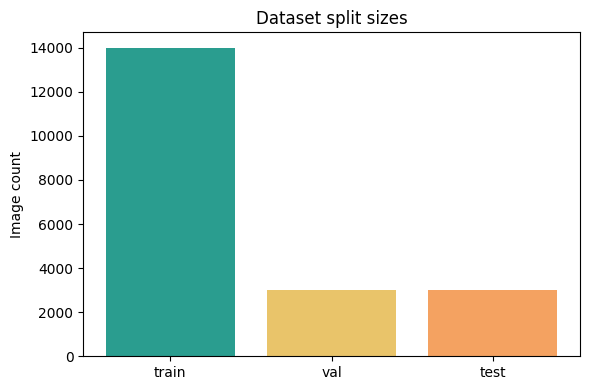

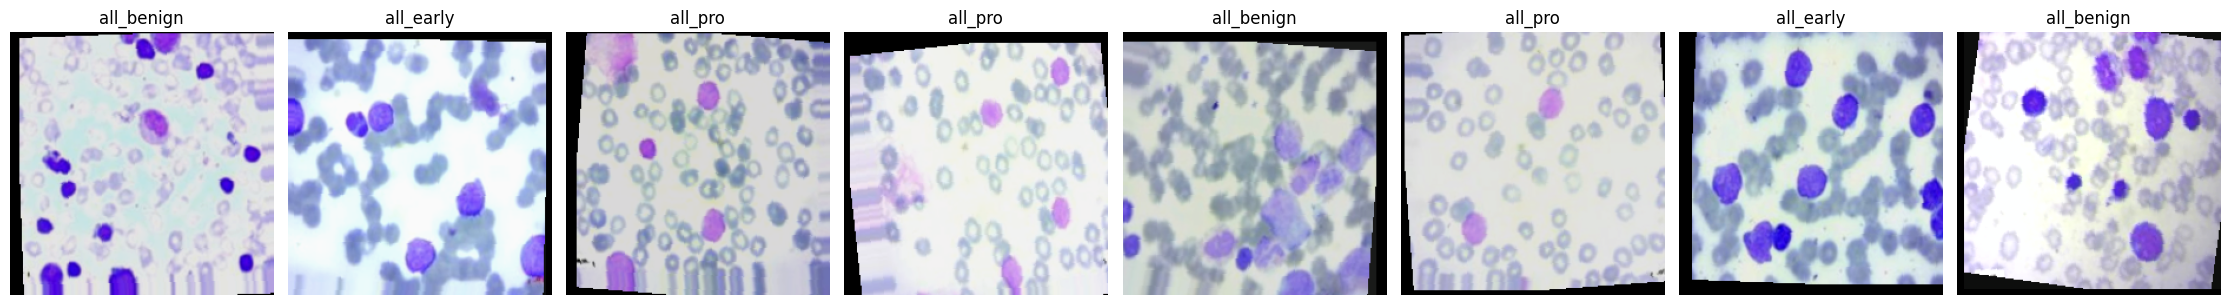

In [5]:
def unnormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)

def show_batch(loader, classes, n=8):
    images, labels = next(iter(loader))
    n = min(n, images.shape[0])
    fig = plt.figure(figsize=(2.8 * n, 3.2))
    for i in range(n):
        ax = fig.add_subplot(1, n, i + 1)
        ax.imshow(unnormalize(images[i]))
        ax.set_title(classes[labels[i].item()])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

split_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}
plt.figure(figsize=(6, 4))
plt.bar(split_sizes.keys(), split_sizes.values(), color=['#2a9d8f', '#e9c46a', '#f4a261'])
plt.ylabel('Image count')
plt.title('Dataset split sizes')
plt.tight_layout()
plt.show()

show_batch(train_loader, class_names, n=8)


In [6]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Class names + split indices used by training/evaluation notebooks
(MODELS_DIR / 'class_names.txt').write_text('\n'.join(class_names) + '\n', encoding='utf-8')
split_payload = {
    'seed': SEED,
    'ratios': {'train': TRAIN_RATIO, 'val': VAL_RATIO, 'test': TEST_RATIO},
    'class_to_idx': base_dataset.class_to_idx,
    'train_indices': train_indices,
    'val_indices': val_indices,
    'test_indices': test_indices,
}
(MODELS_DIR / 'split_indices.json').write_text(json.dumps(split_payload, indent=2), encoding='utf-8')

# Optional domain metadata
domain_map = {}
if DOMAIN_METADATA_CSV is not None and Path(DOMAIN_METADATA_CSV).exists():
    with open(DOMAIN_METADATA_CSV, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            key = Path(row['image_path']).as_posix()
            domain_map[key] = row.get('domain', 'unknown')
    print(f'Loaded domain metadata from {DOMAIN_METADATA_CSV}')

# Dataset manifest for robustness/failure analysis
split_lookup = {}
for i in train_indices:
    split_lookup[i] = 'train'
for i in val_indices:
    split_lookup[i] = 'val'
for i in test_indices:
    split_lookup[i] = 'test'

with open(MANIFEST_PATH, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['index', 'image_path', 'relative_path', 'class_idx', 'class_name', 'split', 'domain', 'mask_exists'])
    for idx, (img_path, cls_idx) in enumerate(base_dataset.samples):
        img_path = Path(img_path)
        rel_path = img_path.relative_to(DATA_DIR).as_posix()
        domain = domain_map.get(rel_path, 'default')

        if MASK_ROOT is not None:
            mask_root = Path(MASK_ROOT)
            stem = img_path.stem
            candidates = [
                mask_root / rel_path,
                mask_root / f'{stem}_mask.png',
                mask_root / f'{stem}.png',
                mask_root / img_path.parent.name / f'{stem}_mask.png',
            ]
            mask_exists = int(any(c.exists() for c in candidates))
        else:
            mask_exists = 0

        writer.writerow([
            idx,
            img_path.as_posix(),
            rel_path,
            cls_idx,
            class_names[cls_idx],
            split_lookup[idx],
            domain,
            mask_exists,
        ])

prep_metadata = {
    'data_dir': str(DATA_DIR),
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'seed': SEED,
    'class_names': class_names,
    'split_sizes': split_sizes,
    'manifest_path': str(MANIFEST_PATH),
    'mask_root': str(MASK_ROOT) if MASK_ROOT is not None else None,
    'domain_metadata_csv': str(DOMAIN_METADATA_CSV) if DOMAIN_METADATA_CSV is not None else None,
}
(MODELS_DIR / 'data_prep_metadata.json').write_text(json.dumps(prep_metadata, indent=2), encoding='utf-8')

print('Saved: models/class_names.txt')
print('Saved: models/split_indices.json')
print(f'Saved: {MANIFEST_PATH}')
print('Saved: models/data_prep_metadata.json')


Saved: models/class_names.txt
Saved: models/split_indices.json
Saved: models/dataset_manifest.csv
Saved: models/data_prep_metadata.json
